In [12]:
import pandas as pd

df = pd.read_csv("/Users/melina/Downloads/dfforbaseline.csv")
print("Loaded dataset shape:", df.shape)


Loaded dataset shape: (13000, 14)


In [13]:
from sklearn.model_selection import train_test_split

target_col = "Decision"

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


X_train: (9100, 13) y_train: (9100,)
X_val: (1950, 13) y_val: (1950,)
X_test: (1950, 13) y_test: (1950,)


Logisticregression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

X = df.drop(columns='Decision')
y = df['Decision']

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X, y)

y_pred = lr_model.predict(X)
y_proba = lr_model.predict_proba(X)[:, 1] 

train_accuracy = accuracy_score(y, y_pred)
train_auc = roc_auc_score(y, y_proba)

train_precision = precision_score(y, y_pred, average=None)
train_recall = recall_score(y, y_pred, average=None)
train_f1 = f1_score(y, y_pred, average=None)

cm = confusion_matrix(y, y_pred)

report = classification_report(y, y_pred)

print(" Training Metrics:")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"AUC: {train_auc:.4f}\n")

print("Confusion Matrix:")
print(cm, "\n")

print("Per-Class Metrics:")
print(report)


 Training Metrics:
Accuracy: 0.6682
AUC: 0.7207

Confusion Matrix:
[[3972 2056]
 [2257 4715]] 

Per-Class Metrics:
              precision    recall  f1-score   support

           0       0.64      0.66      0.65      6028
           1       0.70      0.68      0.69      6972

    accuracy                           0.67     13000
   macro avg       0.67      0.67      0.67     13000
weighted avg       0.67      0.67      0.67     13000



In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression

X = df.drop(columns='Decision')
y = df['Decision']

kf = KFold(n_splits=9, shuffle=True, random_state=42)

lr = LogisticRegression(max_iter=1000, random_state=42)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2'],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=kf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest Hyperparameters (Train CV only):")
print(grid_search.best_params_)
print("Best Train CV AUC:", round(grid_search.best_score_, 4))


Fitting 9 folds for each of 20 candidates, totalling 180 fits



Best Hyperparameters (Train CV only):
{'C': 100, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Train CV AUC: 0.7226


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import pandas as pd

X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

best_lr = LogisticRegression(
    C=100,
    solver='liblinear',
    penalty='l2',
    class_weight=None,
    max_iter=1000,
    random_state=42
)

best_lr.fit(X_train_full, y_train_full)

print(" Logistic Regression retrained on Train + Validation sets.")

y_trainval_pred = best_lr.predict(X_train_full)
y_trainval_proba = best_lr.predict_proba(X_train_full)[:, 1]

print("\nTrain + Validation Metrics (after retraining):")
print("Accuracy:", round(accuracy_score(y_train_full, y_trainval_pred), 4))
print("AUC:", round(roc_auc_score(y_train_full, y_trainval_proba), 4))
print(classification_report(y_train_full, y_trainval_pred))
print(confusion_matrix(y_train_full, y_trainval_pred))


 Logistic Regression retrained on Train + Validation sets.

Train + Validation Metrics (after retraining):
Accuracy: 0.6718
AUC: 0.7217
              precision    recall  f1-score   support

           0       0.64      0.67      0.65      5138
           1       0.70      0.68      0.69      5912

    accuracy                           0.67     11050
   macro avg       0.67      0.67      0.67     11050
weighted avg       0.67      0.67      0.67     11050

[[3426 1712]
 [1915 3997]]


In [17]:
import pandas as pd
import numpy as np


feature_names = X_train_full.columns


coefs = best_lr.coef_[0]  


feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs,
    'Absolute_Coefficient': np.abs(coefs)
})

feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print(feature_importance)


                        Feature  Coefficient  Absolute_Coefficient
11            Target_University   -12.868883             12.868883
10    Target_Program_Discipline     2.861667              2.861667
9                Target_Program    -2.143656              2.143656
6            Target_Degree_Type    -1.415068              1.415068
12               Target_Country     0.336673              0.336673
7              Applicant_Status     0.238260              0.238260
8      Target_University_Status    -0.232847              0.232847
2   Target_University_FSR_Score    -0.218984              0.218984
0                 Applicant_GPA     0.132273              0.132273
1                 Decision_Year    -0.115517              0.115517
3   Target_University_CPF_Score    -0.101966              0.101966
4   Target_University_ISR_Score     0.075964              0.075964
5     Target_University_QS_Rank     0.067312              0.067312


logistic regression with feature interaction

In [18]:
import pandas as pd
from itertools import combinations


most_important_features = [
    'Target_University',
    'Target_Program',
    'Target_Degree_Type',
    'Target_Program_Discipline',
    'Target_University_FSR_Score'
]

X_top = df[most_important_features]


interaction_features = pd.DataFrame()

for f1, f2 in combinations(most_important_features, 2):
    interaction_name = f"{f1}_x_{f2}"
    interaction_features[interaction_name] = X_top[f1] * X_top[f2]


X_final = pd.concat([X_top, interaction_features], axis=1)

print(f" Original features: {len(most_important_features)}")
print(f" Pairwise interaction features created: {interaction_features.shape[1]}")
print(f"Total features after interaction: {X_final.shape[1]}")

print(X_final.head())


 Original features: 5
 Pairwise interaction features created: 10
Total features after interaction: 15
   Target_University  Target_Program  Target_Degree_Type  \
0           0.005154        0.027231                   1   
1           0.003385        0.010385                   1   
2           0.010000        0.083308                   1   
3           0.005308        0.082231                   1   
4           0.022154        0.006308                   1   

   Target_Program_Discipline  Target_University_FSR_Score  \
0                   0.070154                    -0.128730   
1                   0.010385                    -1.148255   
2                   0.087077                    -1.381537   
3                   0.139077                     1.224878   
4                   0.006308                     1.147118   

   Target_University_x_Target_Program  Target_University_x_Target_Degree_Type  \
0                            0.000140                                0.005154   
1       

In [19]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

df['Target_University_x_Applicant_GPA'] = df['Target_University'] * df['Applicant_GPA']
df['Target_Degree_Type_x_Applicant_GPA'] = df['Target_Degree_Type'] * df['Applicant_GPA']
df['Applicant_GPA_x_Decision_Year'] = df['Applicant_GPA'] * df['Decision_Year']

original_features = [
    'Target_University',
    'Target_Program',
    'Target_Degree_Type',
    'Target_Program_Discipline',
    'Target_University_FSR_Score'
]

interaction_features = [
    'Target_University_x_Applicant_GPA',
    'Target_Degree_Type_x_Applicant_GPA',
    'Applicant_GPA_x_Decision_Year'
]

X_final = df[original_features + interaction_features]
y = df['Decision']

print(f" Total features used: {X_final.shape[1]}")

best_lr = LogisticRegression(
    C=100,
    penalty='l2',
    solver='liblinear',  
    max_iter=1000,
    random_state=42
)

best_lr.fit(X_final, y)

y_pred = best_lr.predict(X_final)
y_proba = best_lr.predict_proba(X_final)[:, 1]

train_accuracy = accuracy_score(y, y_pred)
train_auc = roc_auc_score(y, y_proba)
cm = confusion_matrix(y, y_pred)
report = classification_report(y, y_pred, digits=4)

print("Training Metrics with Top Features + Interactions:\n")
print("Confusion Matrix:")
print(cm, "\n")
print("Per-Class Metrics:")
print(report)
print(f"AUC: {train_auc:.4f}")
print(f"Accuracy: {train_accuracy:.4f}")


 Total features used: 8


Training Metrics with Top Features + Interactions:

Confusion Matrix:
[[4030 1998]
 [2302 4670]] 

Per-Class Metrics:
              precision    recall  f1-score   support

           0     0.6364    0.6685    0.6521      6028
           1     0.7004    0.6698    0.6848      6972

    accuracy                         0.6692     13000
   macro avg     0.6684    0.6692    0.6684     13000
weighted avg     0.6707    0.6692    0.6696     13000

AUC: 0.7144
Accuracy: 0.6692


Based on logistic regression feature importance, three pairwise polynomial interaction features (`Target_Degree_Type_x_Applicant_GPA`, `Target_University_x_Applicant_GPA`, and `Applicant_GPA_x_Decision_Year`) were created and added to the dataset. However, including these interactions led to only a marginal improvement in model performance. This indicates that these interaction features do not provide meaningful predictive gain, and the model’s performance remains largely the same using only the original features. Therefore, for simplicity and interpretability, it is recommended to retain only the original features without including these polynomial interactions.


In [20]:

interaction_features = [
    'Target_Degree_Type_x_Applicant_GPA',
    'Target_University_x_Applicant_GPA',
    'Applicant_GPA_x_Decision_Year'
]

df = df.drop(columns=[col for col in interaction_features if col in df.columns])
df.head()


,Decision,Applicant_GPA,Decision_Year,Target_University_FSR_Score,Target_University_CPF_Score,Target_University_ISR_Score,Target_University_QS_Rank,Target_Degree_Type,Applicant_Status,Target_University_Status,Target_Program,Target_Program_Discipline,Target_University,Target_Country
0,1,-3.302371,1.316414,-0.128730,1.363850,-1.107856,-0.671909,1,1.0,1.0,0.027231,0.070154,0.005154,0.001077
1,1,-1.853384,1.316414,-1.148255,0.595068,1.191774,-0.623350,1,1.0,1.0,0.010385,0.010385,0.003385,0.001077
2,1,0.429870,1.316414,-1.381537,-0.052327,-0.159258,0.050401,1,2.0,1.0,0.083308,0.087077,0.010000,0.845308
3,1,-0.228761,1.316414,1.224878,0.944515,1.115120,-0.802410,1,2.0,1.0,0.082231,0.139077,0.005308,0.035846
4,0,0.825048,1.316414,1.147118,0.558285,1.105538,-0.781166,1,2.0,2.0,0.006308,0.006308,0.022154,0.845308


Decision tree

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

X = df.drop(columns='Decision')
y = df['Decision']

dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

dt_model.fit(X, y)

y_pred = dt_model.predict(X)
y_proba = dt_model.predict_proba(X)[:, 1] 

train_accuracy = accuracy_score(y, y_pred)
train_auc = roc_auc_score(y, y_proba)

train_precision = precision_score(y, y_pred, average=None)
train_recall = recall_score(y, y_pred, average=None)
train_f1 = f1_score(y, y_pred, average=None)

cm = confusion_matrix(y, y_pred)

report = classification_report(y, y_pred)

print(" Training Metrics (Decision Tree):")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"AUC: {train_auc:.4f}\n")

print("Confusion Matrix:")
print(cm, "\n")

print("Per-Class Metrics:")
print(report)


 Training Metrics (Decision Tree):
Accuracy: 0.9904
AUC: 0.9998

Confusion Matrix:
[[6021    7]
 [ 118 6854]] 

Per-Class Metrics:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6028
           1       1.00      0.98      0.99      6972

    accuracy                           0.99     13000
   macro avg       0.99      0.99      0.99     13000
weighted avg       0.99      0.99      0.99     13000



In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix


dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 8, 12, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

kf = KFold(n_splits=9, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=kf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n Best Hyperparameters:", grid_search.best_params_)
print("Best Train CV AUC:", round(grid_search.best_score_, 4))



Fitting 9 folds for each of 160 candidates, totalling 1440 fits

 Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 2}
Best Train CV AUC: 0.7321


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import pandas as pd


best_params = {
    'criterion': 'gini',
    'max_depth': 8,
    'min_samples_split': 20,
    'min_samples_leaf': 8,
    'random_state': 42
}

best_dt = DecisionTreeClassifier(**best_params)

X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

best_dt.fit(X_train_full, y_train_full)
print(" Decision Tree trained on TRAIN + VALIDATION.")

y_trainval_pred = best_dt.predict(X_train_full)
y_trainval_proba = best_dt.predict_proba(X_train_full)[:, 1]

print("\n📊 Train + Validation Metrics:")
print("Accuracy:", round(accuracy_score(y_train_full, y_trainval_pred), 4))
print("AUC:", round(roc_auc_score(y_train_full, y_trainval_proba), 4))
print("\nClassification Report:")
print(classification_report(y_train_full, y_trainval_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_train_full, y_trainval_pred))


 Decision Tree trained on TRAIN + VALIDATION.

📊 Train + Validation Metrics:
Accuracy: 0.7237
AUC: 0.7982

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.67      0.69      5138
           1       0.73      0.77      0.75      5912

    accuracy                           0.72     11050
   macro avg       0.72      0.72      0.72     11050
weighted avg       0.72      0.72      0.72     11050

Confusion Matrix:
[[3437 1701]
 [1352 4560]]


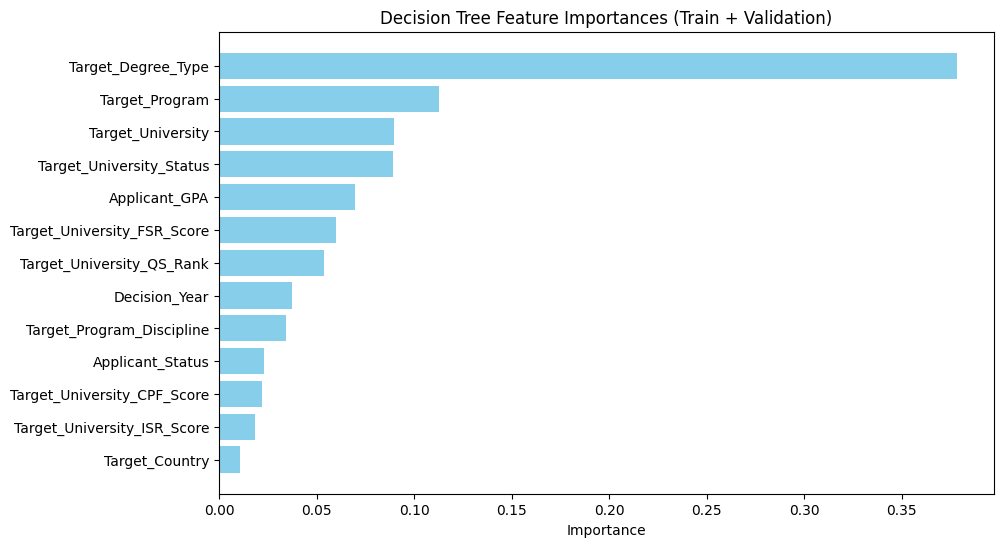


Feature Importances (Train + Validation):
                        Feature  Importance
0            Target_Degree_Type    0.378317
1                Target_Program    0.112978
2             Target_University    0.089651
3      Target_University_Status    0.089280
4                 Applicant_GPA    0.069771
5   Target_University_FSR_Score    0.060215
6     Target_University_QS_Rank    0.053907
7                 Decision_Year    0.037542
8     Target_Program_Discipline    0.034326
9              Applicant_Status    0.022826
10  Target_University_CPF_Score    0.021989
11  Target_University_ISR_Score    0.018550
12               Target_Country    0.010650


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Importance': best_dt.feature_importances_
})

feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.gca().invert_yaxis() 
plt.xlabel('Importance')
plt.title('Decision Tree Feature Importances (Train + Validation)')
plt.show()

print("\nFeature Importances (Train + Validation):")
print(feature_importances.reset_index(drop=True))


Top 10 Features Driving Admission Decisions:

 Rank                     Feature  Importance
    1               Applicant_GPA       0.205
    2              Target_Program       0.141
    3   Target_Program_Discipline       0.119
    4          Target_Degree_Type       0.104
    5               Decision_Year       0.091
    6           Target_University       0.060
    7   Target_University_QS_Rank       0.057
    8 Target_University_ISR_Score       0.056
    9 Target_University_FSR_Score       0.054
   10 Target_University_CPF_Score       0.046

Full Decision Tree Rules (Readable Format):

|--- Target_Degree_Type <= 1.50
|   |--- Target_University_QS_Rank <= -0.39
|   |   |--- Target_Program <= 0.08
|   |   |   |--- Target_University_QS_Rank <= -0.80
|   |   |   |   |--- Target_Program_Discipline <= 0.05
|   |   |   |   |   |--- Applicant_GPA <= 0.50
|   |   |   |   |   |   |--- Target_University <= 0.01
|   |   |   |   |   |   |   |--- Applicant_GPA <= -0.23
|   |   |   |   |   |   |

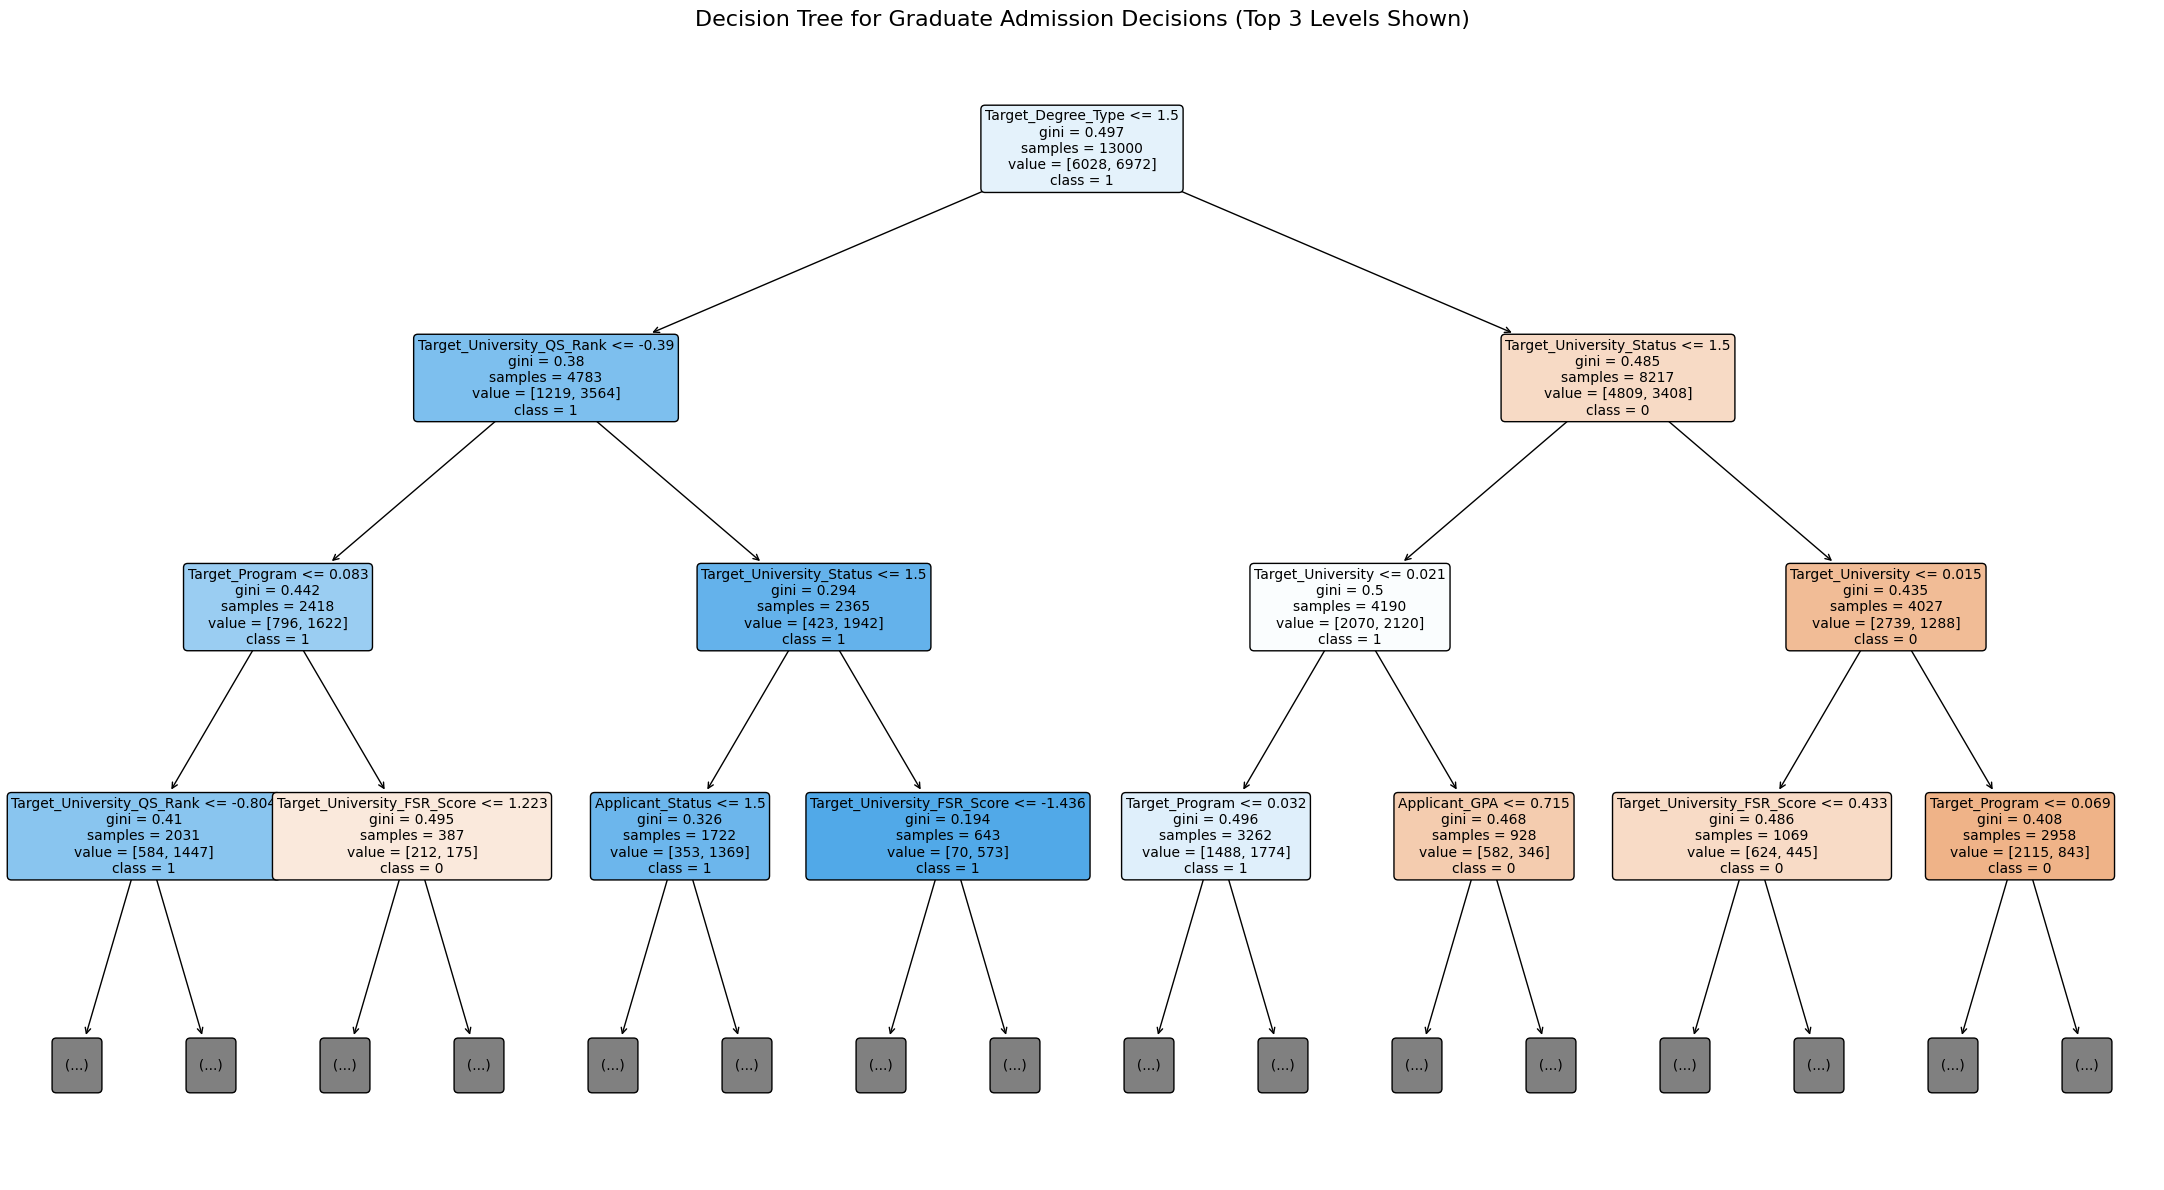

<Figure size 640x480 with 0 Axes>

In [25]:
from sklearn.tree import export_text, plot_tree
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance['Rank'] = range(1, len(feature_importance) + 1)
feature_importance = feature_importance[['Rank', 'Feature', 'Importance']]

feature_importance['Importance'] = feature_importance['Importance'].round(3)

top_features = feature_importance.head(10)
print("Top 10 Features Driving Admission Decisions:\n")
print(top_features.to_string(index=False))

top_features.to_csv("feature_importances_top10.csv", index=False)


tree_rules = export_text(dt_model, feature_names=list(X_train_full.columns))
print("\nFull Decision Tree Rules (Readable Format):\n")
print(tree_rules)

primary_split = top_features.iloc[0]['Feature']
secondary_split = top_features.iloc[1]['Feature']
tertiary_split = top_features.iloc[2]['Feature']

narrative = f"""
The decision tree analysis revealed a clear hierarchical structure in the admissions process.
The primary factor, {primary_split}, separates applicants into distinct groups.
For applicants in the first group, {secondary_split} significantly influences outcomes,
followed by {tertiary_split} as a finer distinction. These top three features capture the
majority of variance in admission decisions, highlighting that admissions are influenced
by a combination of applicant-level characteristics and institutional factors.
"""

print("\nNarrative Summary for Paper:\n")
print(narrative)


plt.figure(figsize=(22,12))
plot_tree(
    dt_model,
    feature_names=X_train_full.columns,
    class_names=[str(c) for c in dt_model.classes_],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3 
)
plt.title("Decision Tree for Graduate Admission Decisions (Top 3 Levels Shown)", fontsize=16)
plt.tight_layout()
plt.show()

plt.savefig("decision_tree_plot.png", dpi=300)


In [26]:
from sklearn.tree import export_text

tree_rules_top3 = export_text(
    dt_model,
    feature_names=list(X_train_full.columns),
    max_depth=3
)

print("\nDecision Tree Rules (Top 3 Levels Only):\n")
print(tree_rules_top3)



Decision Tree Rules (Top 3 Levels Only):

|--- Target_Degree_Type <= 1.50
|   |--- Target_University_QS_Rank <= -0.39
|   |   |--- Target_Program <= 0.08
|   |   |   |--- Target_University_QS_Rank <= -0.80
|   |   |   |   |--- truncated branch of depth 14
|   |   |   |--- Target_University_QS_Rank >  -0.80
|   |   |   |   |--- truncated branch of depth 25
|   |   |--- Target_Program >  0.08
|   |   |   |--- Target_University_FSR_Score <= 1.22
|   |   |   |   |--- truncated branch of depth 15
|   |   |   |--- Target_University_FSR_Score >  1.22
|   |   |   |   |--- truncated branch of depth 9
|   |--- Target_University_QS_Rank >  -0.39
|   |   |--- Target_University_Status <= 1.50
|   |   |   |--- Applicant_Status <= 1.50
|   |   |   |   |--- truncated branch of depth 21
|   |   |   |--- Applicant_Status >  1.50
|   |   |   |   |--- truncated branch of depth 21
|   |   |--- Target_University_Status >  1.50
|   |   |   |--- Target_University_FSR_Score <= -1.44
|   |   |   |   |--- trunc

in more details
Overall, the decision tree structure confirms that Target_Degree_Type is the primary driver of admission outcomes, effectively separating applicants into two distinct decision regimes.

For Master’s applicants (Target_Degree_Type ≤ 1.50), admission decisions are dominated by institutional quality and program-level alignment rather than applicant-level signals alone. In particular, Target_University_QS_Rank acts as the earliest and most influential splitter, indicating that institutional prestige strongly conditions subsequent decisions. Within this group, Target_Program, Target_Program_Discipline, and Applicant_GPA jointly refine outcomes, suggesting that once university quality is accounted for, academic fit and performance determine acceptance. University reputation sub-dimensions (ISR, FSR, CPF scores) appear repeatedly but mostly as secondary refinements, while temporal effects (Decision_Year) play only a marginal role.

In contrast, for PhD applicants (Target_Degree_Type > 1.50), the decision process shifts toward a more research-oriented and performance-sensitive evaluation. While Target_University and its research-related indicators (notably FSR and ISR scores) remain influential, Applicant_GPA becomes substantially more decisive compared to the Master’s branch. The tree reveals frequent interactions between GPA, university research strength, and program discipline, reflecting a stronger emphasis on individual academic capability and research fit. Additionally, Applicant_Status and Decision_Year appear more often in deeper splits, indicating that contextual and temporal factors play a relatively larger role in PhD-level decisions.

Therefore, the model suggests a clear structural distinction: Master’s admissions are primarily driven by institutional prestige and program alignment, whereas PhD admissions are dominated by applicant academic strength and research-oriented university characteristics, with contextual factors exerting a secondary but non-negligible influence.

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import pandas as pd

best_params = {
    'criterion': 'gini',
    'max_depth': 8,
    'min_samples_split': 20,
    'min_samples_leaf': 8,
    'random_state': 42
}

best_dt = DecisionTreeClassifier(**best_params)

X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

best_dt.fit(X_train_full, y_train_full)
print(" Decision Tree trained on TRAIN + VALIDATION.")

y_trainval_pred = best_dt.predict(X_train_full)
y_trainval_proba = best_dt.predict_proba(X_train_full)[:, 1]

print("\n📊 Train + Validation Metrics:")
print("Accuracy:", round(accuracy_score(y_train_full, y_trainval_pred), 4))
print("AUC:", round(roc_auc_score(y_train_full, y_trainval_proba), 4))
print("\nClassification Report:")
print(classification_report(y_train_full, y_trainval_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_train_full, y_trainval_pred))


 Decision Tree trained on TRAIN + VALIDATION.

📊 Train + Validation Metrics:
Accuracy: 0.7237
AUC: 0.7982

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.67      0.69      5138
           1       0.73      0.77      0.75      5912

    accuracy                           0.72     11050
   macro avg       0.72      0.72      0.72     11050
weighted avg       0.72      0.72      0.72     11050

Confusion Matrix:
[[3437 1701]
 [1352 4560]]


As we described, the decision tree branches show that the most influential factor driving admissions decisions is university quality metrics. While a feature representing domain knowledge, such as “target university competitiveness,” could be created, the model already includes comprehensive university quality indicators. Adding such a feature would likely not improve performance and could even introduce high multicollinearity with existing metrics. Moving to the second most important factor, Applicant_GPA clearly signals applicant-level quality. The third shared influential factor is Target_Program and Target_Program_Discipline, which led us to consider including program-specific admission rates. By quantifying the number of accepted applicants per program relative to total applicants, we can capture the degree of program competitiveness, reflecting real-world admission trends—especially for highly competitive fields like AI and Computer Science. Moreover, since Target_University_QS_Rank and Target_Program appear relatively as the first and third most influential indicators, we decided to create an interaction feature between program and QS rank, capturing how program choice interacts with university prestige in shaping admissions outcomes.

In [28]:
import pandas as pd

df['Accepted'] = (df['Decision'] == 1).astype(int)

program_stats = df.groupby('Target_Program')['Accepted'].agg(['sum', 'count']).reset_index()
program_stats['Program_Admission_Rate'] = program_stats['sum'] / program_stats['count']

df = df.merge(program_stats[['Target_Program', 'Program_Admission_Rate']], 
              on='Target_Program', 
              how='left')

df['Program_x_QS_Rank'] = df['Target_Program'] * df['Target_University_QS_Rank']

df.drop(columns=['Accepted'], inplace=True)
df.head(5)


,Decision,Applicant_GPA,Decision_Year,Target_University_FSR_Score,Target_University_CPF_Score,Target_University_ISR_Score,Target_University_QS_Rank,Target_Degree_Type,Applicant_Status,Target_University_Status,Target_Program,Target_Program_Discipline,Target_University,Target_Country,Program_Admission_Rate,Program_x_QS_Rank
0,1,-3.302371,1.316414,-0.128730,1.363850,-1.107856,-0.671909,1,1.0,1.0,0.027231,0.070154,0.005154,0.001077,0.629944,-0.018297
1,1,-1.853384,1.316414,-1.148255,0.595068,1.191774,-0.623350,1,1.0,1.0,0.010385,0.010385,0.003385,0.001077,0.570370,-0.006473
2,1,0.429870,1.316414,-1.381537,-0.052327,-0.159258,0.050401,1,2.0,1.0,0.083308,0.087077,0.010000,0.845308,0.541090,0.004199
3,1,-0.228761,1.316414,1.224878,0.944515,1.115120,-0.802410,1,2.0,1.0,0.082231,0.139077,0.005308,0.035846,0.670720,-0.065983
4,0,0.825048,1.316414,1.147118,0.558285,1.105538,-0.781166,1,2.0,2.0,0.006308,0.006308,0.022154,0.845308,0.597561,-0.004927


In [29]:
# Save as CSV in Downloads
df.to_csv("/Users/melina/Downloads/finalpaperdataset.csv", index=False)

# Or save as a pickle file in Downloads
df.to_pickle("/Users/melina/Downloads/finalpaperdataset.pkl")
